### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 
from pulse_optimization import *
import sympy as sp

In [2]:
rH = 2
rW = 1
def fitted_pulse_symbolic(t, p):
    tg_sym, wd_sym, amp_sym = p
    return amp_sym, wd_sym
param_ranges = {"wd_offset": (-0.005, 0.005), "amp_scale": (0.8, 1.2)}
param_names = list(param_ranges.keys())

f_ref = 0.05572
s_ref = Simulation(f_c_dc=f_ref)
s_sym, f_c_dc_sym = make_symbolic_bias_simulation(s_ref, f_ref=f_ref)
def fitted_pulse_symbolic_with_bias(t, parameters):
    return fitted_pulse_symbolic(t, parameters[:3])
H_bias_base, M_bias_base, M_inv_0_bias_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic_with_bias, p_names=["tg", "wd", "amp", "f_c_dc"], s=s_sym, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=True)

def bind_bias_floquet_functions(tg_target, f_c_dc, s_bias, H_bias_base=H_bias_base, M_bias_base=M_bias_base, M_inv_0_bias_base=M_inv_0_bias_base):
    cos_wd, cos_amp = compute_cos_params(s_bias, tg_target)
    def absolute_parameters(offsets):
        values = dict(zip(param_names, offsets))
        return cos_wd + values["wd_offset"], cos_amp * values["amp_scale"]
    def H_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return H_bias_base(t, tg_target, wd, amp, f_c_dc)
    def M_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return M_bias_base(t, tg_target, wd, amp, f_c_dc)
    def M_inv_0_func(*offsets):
        wd, amp = absolute_parameters(offsets)
        return M_inv_0_bias_base(tg_target, wd, amp, f_c_dc)
    H_func.is_time_dependent = getattr(H_bias_base, "is_time_dependent", True)
    return H_func, M_func, M_inv_0_func


1/2 Erstelle symbolischen Puls und berechne W und Heff ...


W-Floquet order r=1/1: 100%|██████████| 81/81 [00:00<00:00, 440.87it/s]


✅ W-elements calculation completed.
Calculating effective matrix elements (3x3)...


H_eff matrix elements: 100%|██████████| 9/9 [00:00<00:00,  9.54it/s]


✅ H_eff matrix calculation completed.
2/2 Erzeuge Lambdified H_func, M_func und M_inv_0_func ...
Operationen in Heff vor CSE: 4089


In [3]:
# from scipy.optimize import minimize_scalar

# tg_fixed = 550.0

# def objective_bias(f_c_dc, correct_zz=False):
#     f_c_dc = float(np.atleast_1d(f_c_dc)[0])
#     s_bias = Simulation(f_c_dc=f_c_dc)
#     H_func, M_func, M_inv_0_func = bind_bias_floquet_functions(tg_fixed, f_c_dc, s_bias, H_bias_base, M_bias_base, M_inv_0_bias_base)
#     result = optimize_iswap_at_gate_time(tg_fixed, s_bias, param_ranges, H_func, M_func, M_inv_0_func, verbose=False, correct_zz=correct_zz)
#     print(f"f_c_dc = {f_c_dc:+.8f} GHz, infidelity = {result['infid_direct_proc']:.3e}")
#     return result["infid_direct_proc"]

# opt_bias = minimize_scalar(objective_bias, bounds=(+0.055, 0.058), method="bounded", options={"xatol": 1e-5, "maxiter": 15})
# print(f"\nOptimal f_c_dc: {opt_bias.x:+.8f} GHz")
# print(f"Minimum infid_direct_proc: {opt_bias.fun:.6e}")

In [ ]:
tg_fixed = 550.0
f_c_dc_list = np.linspace(0.05552, 0.0558, 10)  # Coupler-frequency offset [GHz]

results_bias = []

for f_c_dc in tqdm(f_c_dc_list):
    f_c_dc = float(np.atleast_1d(f_c_dc)[0])
    s_bias = Simulation(f_c_dc=f_c_dc)
    H_func, M_func, M_inv_0_func = bind_bias_floquet_functions(tg_fixed, f_c_dc, s_bias)
    result = optimize_iswap_at_gate_time_cos(tg_fixed, s_bias, param_ranges, H_func, M_func, M_inv_0_func, verbose=False)
    result["f_c_dc"] = f_c_dc
    results_bias.append(result)

result_keys_bias = results_bias[0].keys()
sweep_data_bias = {key: np.asarray([result[key] for result in results_bias]) for key in result_keys_bias}

 10%|█         | 1/10 [00:05<00:53,  5.99s/it]

tg_final: 549.1026 ns | infid_floq_pop: 5.8406e-04 | infid_floq_proc: 3.7316e-04 | infid_direct_pop: 6.0255e-04 | infid_direct_proc: 6.1754e-04


 20%|██        | 2/10 [00:11<00:47,  5.99s/it]

tg_final: 549.1025 ns | infid_floq_pop: 5.7629e-04 | infid_floq_proc: 3.6510e-04 | infid_direct_pop: 5.5803e-04 | infid_direct_proc: 5.6394e-04


 30%|███       | 3/10 [00:18<00:42,  6.03s/it]

...

tg_final: 549.1020 ns | infid_floq_pop: 5.2866e-04 | infid_floq_proc: 4.1721e-04 | infid_direct_pop: 3.8254e-04 | infid_direct_proc: 4.5323e-04


 90%|█████████ | 9/10 [00:53<00:05,  5.77s/it]

tg_final: 549.1019 ns | infid_floq_pop: 5.2130e-04 | infid_floq_proc: 4.4288e-04 | infid_direct_pop: 3.7104e-04 | infid_direct_proc: 4.7282e-04


100%|██████████| 10/10 [00:58<00:00,  5.88s/it]

tg_final: 549.1019 ns | infid_floq_pop: 5.1433e-04 | infid_floq_proc: 4.7341e-04 | infid_direct_pop: 3.6505e-04 | infid_direct_proc: 5.0388e-04


In [5]:

# without bias
s = Simulation()
tg = 550
H_base, M_base, M_inv_0_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic, p_names=["tg", "wd", "amp"], s=s, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=True)

param_ranges = {"wd_offset": (-0.005, 0.005), "amp_scale": (0.8, 1.2)}
param_names = list(param_ranges.keys())

def bind_tg_fixed_floquet_functions(tg_target, s): 
    
    cos_wd, cos_amp = compute_cos_params(s, tg_target)
    def absolute_parameters(offsets):
        values = dict(zip(param_names, offsets))
        return cos_wd + values["wd_offset"], cos_amp * values["amp_scale"]

    def H_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return H_base(t, tg_target, wd, amp)

    def M_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return M_base(t, tg_target, wd, amp)
    def M_inv_0_func(*offsets):
        wd, amp = absolute_parameters(offsets)
        return M_inv_0_base(tg_target, wd, amp)
    H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)
    return H_func, M_func, M_inv_0_func

dic = optimize_iswap_at_gate_time_cos(tg, s, param_ranges, *bind_tg_fixed_floquet_functions(tg, s), verbose = False)


1/2 Erstelle symbolischen Puls und berechne W und Heff ...


W-Floquet order r=1/1: 100%|██████████| 81/81 [00:00<00:00, 1059.67it/s]


✅ W-elements calculation completed.
Calculating effective matrix elements (3x3)...


H_eff matrix elements: 100%|██████████| 9/9 [00:00<00:00, 63.00it/s]


✅ H_eff matrix calculation completed.
2/2 Erzeuge Lambdified H_func, M_func und M_inv_0_func ...
Operationen in Heff vor CSE: 723
tg_final: 550.6503 ns | infid_floq_pop: 2.2980e-04 | infid_floq_proc: 2.4460e-04 | infid_direct_pop: 4.6729e-04 | infid_direct_proc: 7.3477e-02


/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_67905/3140081011.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.035, 0.02, 0.98, 1.0))


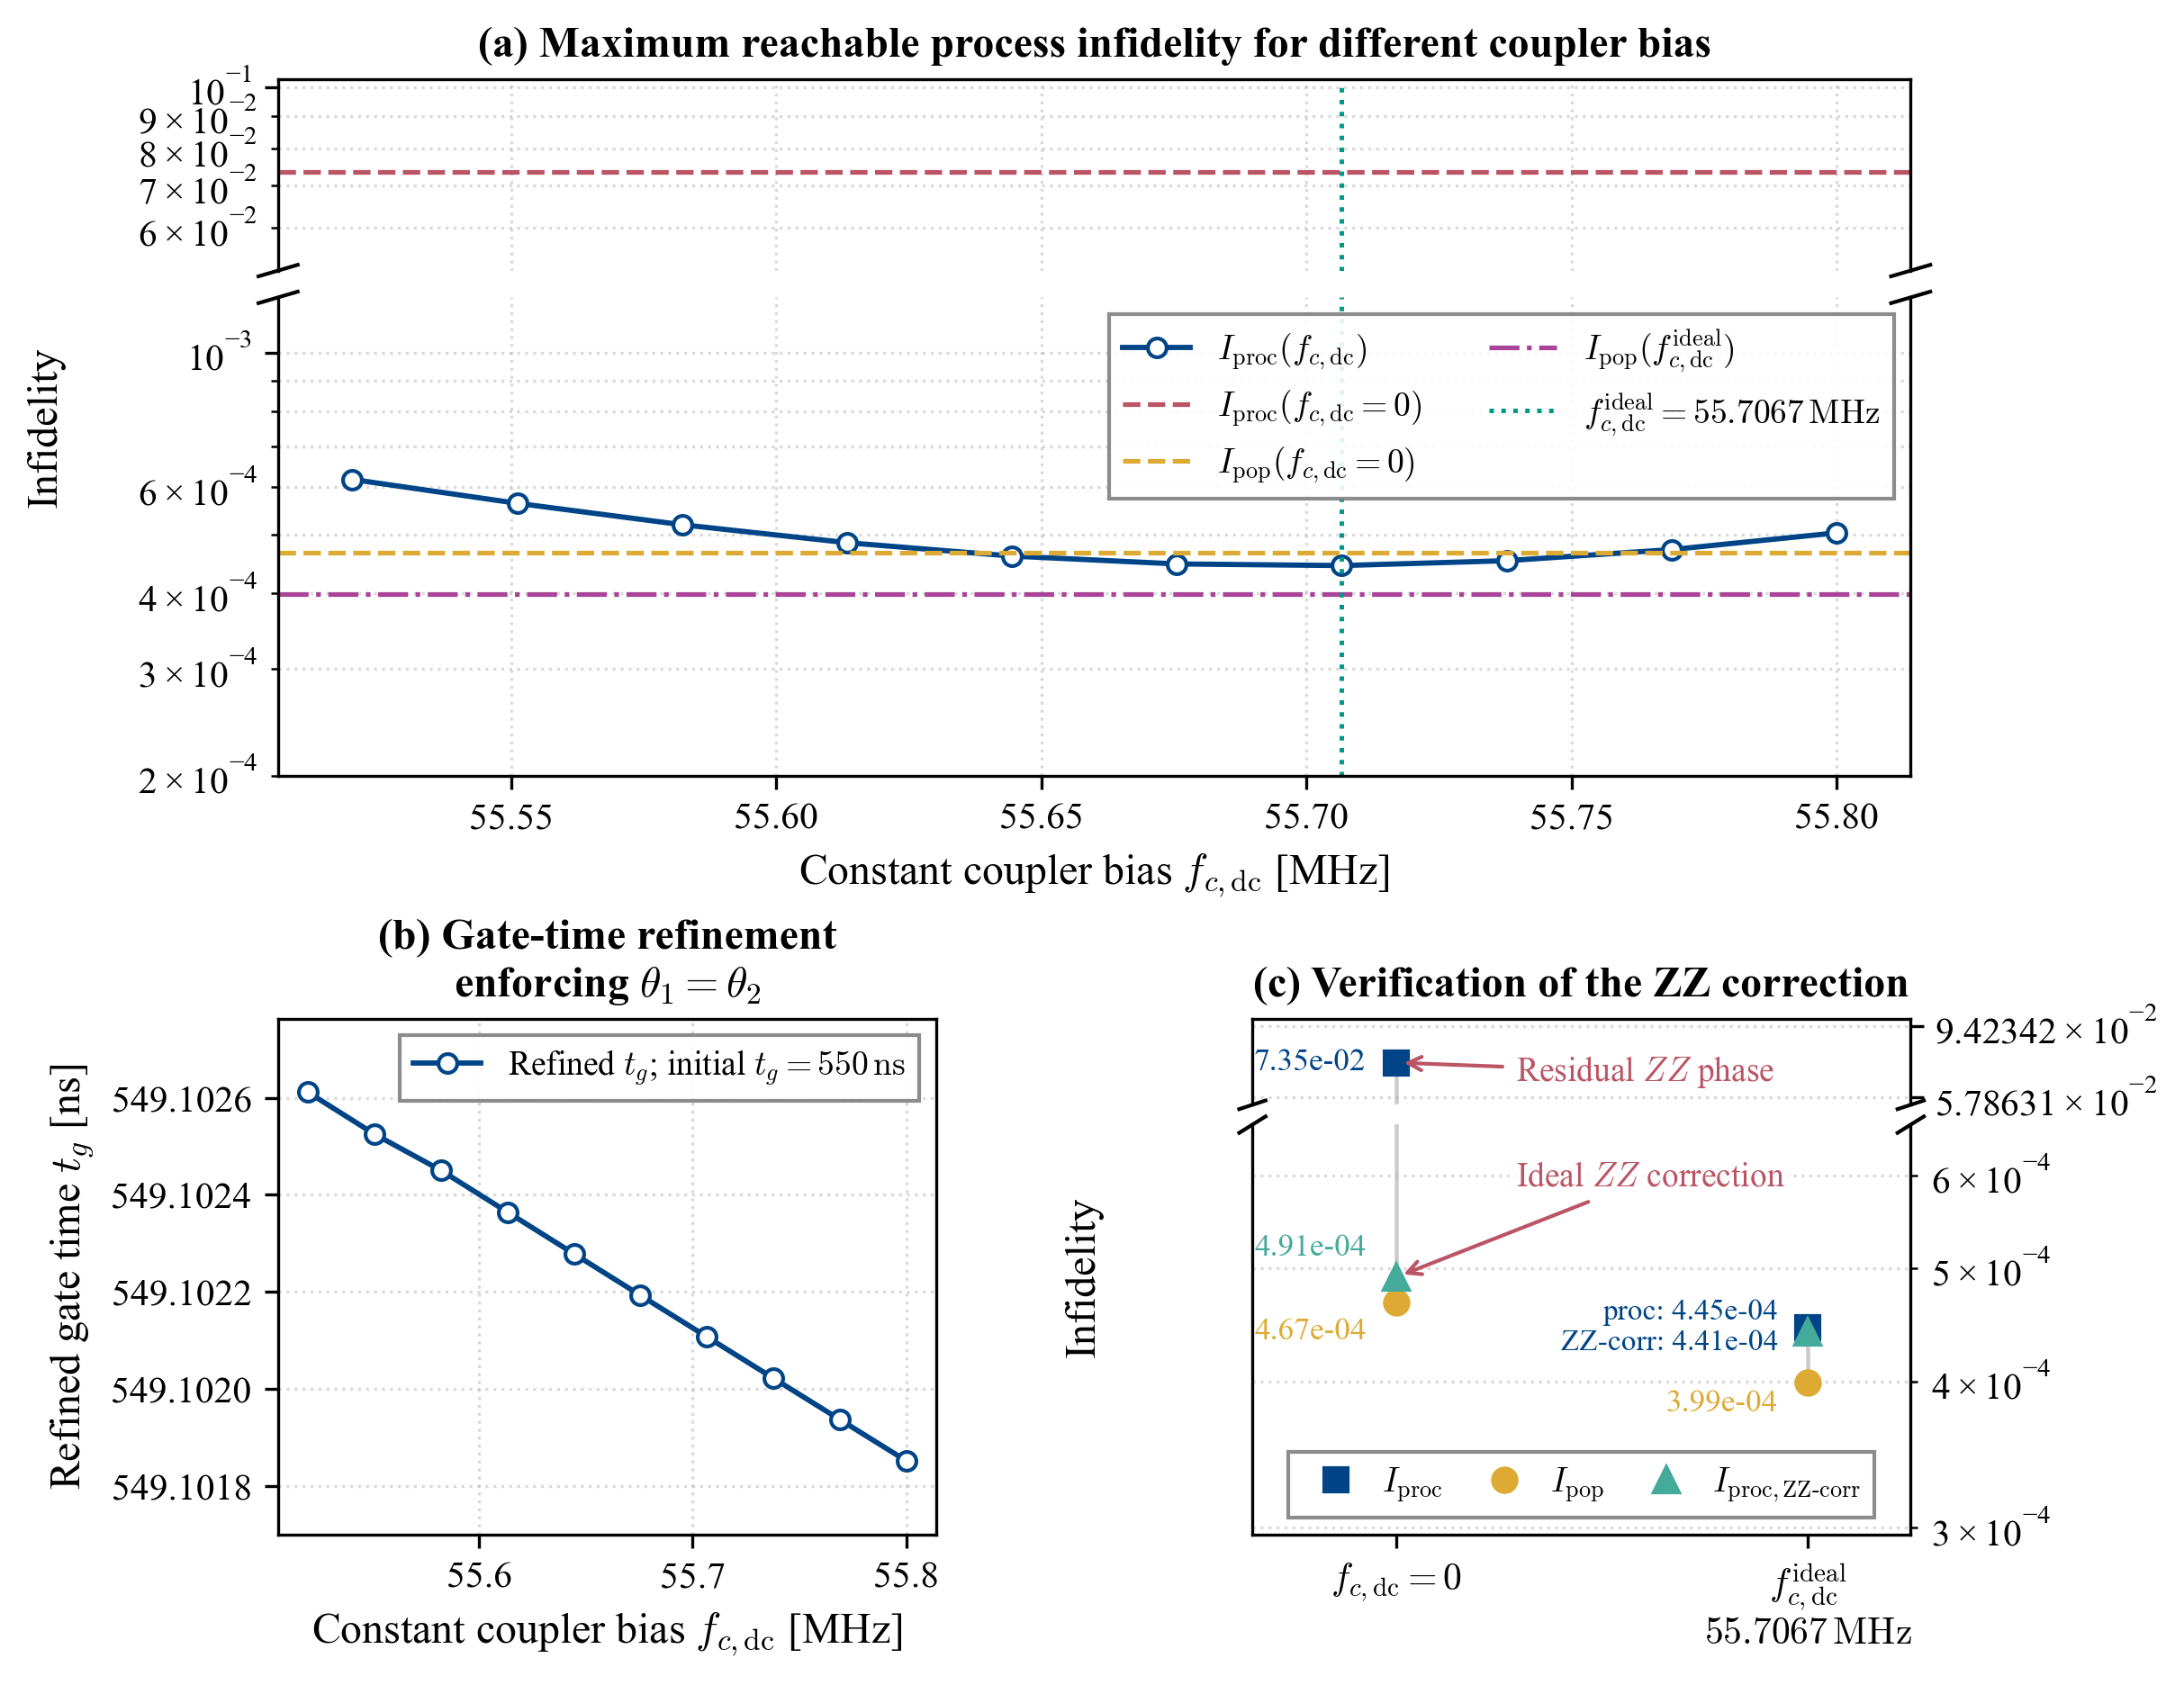

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 11.5,
        "font.size": 11,
        "legend.fontsize": 9.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 12,
        "axes.titlesize": 11.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 5.0,
    })

def _extract_zz_corrected_key(d):
    """Safely finds the ZZ-corrected key even with surrounding spaces."""
    for key in d.keys():
        if "infid_direct_proc_zz" in key:
            return key
    raise KeyError("Could not find 'infid_direct_proc_zzcorrected' in dictionary keys.")


def _set_log_limits_from_values(ax, values, relative_padding=0.12, minimum_span_decades=0.40):
    """Zooms a logarithmic axis around the supplied positive values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0.0)]

    if len(values) == 0:
        raise ValueError("No positive finite values available for logarithmic scaling.")

    log_values = np.log10(values)
    log_min = np.min(log_values)
    log_max = np.max(log_values)
    data_span = log_max - log_min
    target_span = max((1.0 + 2.0 * relative_padding) * data_span, minimum_span_decades)
    center = 0.5 * (log_min + log_max)

    ax.set_ylim(10.0 ** (center - 0.5 * target_span), 10.0 ** (center + 0.5 * target_span))


def plot_constant_bias_fidelity_results(
    f_c_dc_list,
    sweep_data_bias,
    zero_bias_result,
    tg_base=550.0,
    save_path="Figure/constant_bias_fidelity_comparison.pdf",
    show=True
):
    setup_paper_style()

    # Copies prevent accidental modification of the expensive sweep data.
    bias_ghz = np.array(f_c_dc_list, dtype=float, copy=True)
    bias_mhz = 1e3 * bias_ghz
    data = {key.strip(): np.array(value, copy=True) for key, value in sweep_data_bias.items()}

    required_keys = ["infid_direct_proc", "infid_direct_pop", "tg_final"]
    missing_keys = [key for key in required_keys if key not in data]

    if missing_keys:
        raise KeyError(f"Missing sweep-data keys: {missing_keys}")

    if any(len(data[key]) != len(bias_ghz) for key in required_keys):
        raise ValueError("All sweep arrays must have the same length as f_c_dc_list.")

    proc_sweep = np.asarray(data["infid_direct_proc"], dtype=float)
    pop_sweep = np.asarray(data["infid_direct_pop"], dtype=float)
    tg_sweep = np.asarray(data["tg_final"], dtype=float)

    # Optimal bias from the minimum of the direct process infidelity.
    ideal_idx = int(np.nanargmin(proc_sweep))
    ideal_bias_ghz = float(bias_ghz[ideal_idx])
    ideal_bias_mhz = 1e3 * ideal_bias_ghz

    # Zero-bias values.
    zero_proc = float(zero_bias_result["infid_direct_proc"])
    zero_pop = float(zero_bias_result["infid_direct_pop"])
    zero_tg = float(zero_bias_result["tg_final"])
    zero_zz_key = _extract_zz_corrected_key(zero_bias_result)
    zero_zz = float(zero_bias_result[zero_zz_key])

    # Optimal-bias values.
    ideal_proc = float(proc_sweep[ideal_idx])
    ideal_pop = float(pop_sweep[ideal_idx])
    ideal_tg = float(tg_sweep[ideal_idx])
    sweep_zz_key = _extract_zz_corrected_key(data)
    ideal_zz = float(data[sweep_zz_key][ideal_idx])

    if np.any(proc_sweep <= 0.0) or min(zero_proc, zero_pop, zero_zz, ideal_proc, ideal_pop, ideal_zz) <= 0.0:
        raise ValueError("All plotted infidelities must be positive for logarithmic axes.")

    # High-contrast publication colors.
    c_proc = "#004488"
    c_pop = "#DDAA33"
    c_pop_ideal = "#AA4499"
    c_zz = "#44AA99"
    c_opt = "#009988"
    c_zero = "#BB5566"
    c_connector = "#CCCCCC"

    mark_stride = max(1, len(bias_mhz) // 25)

    fig = plt.figure(figsize=(7.8, 7.0), dpi=300)

    # Overall panel structure
    outer_grid = fig.add_gridspec(2, 1, height_ratios=[1.35, 1.0], hspace=0.40)

    # Panel (a): broken y-axis.
    grid_a = outer_grid[0].subgridspec(2, 1, height_ratios=[1, 2.5], hspace=0.08)
    ax_proc_top = fig.add_subplot(grid_a[0])
    ax_proc_bot = fig.add_subplot(grid_a[1], sharex=ax_proc_top)

    # Panels (b) and (c).
    grid_bc = outer_grid[1].subgridspec(1, 2, wspace=0.48)
    ax_tg = fig.add_subplot(grid_bc[0])

    # Lower segment of panel (c).
    grid_c = grid_bc[1].subgridspec(2, 1, height_ratios=[0.80, 3.80], hspace=0.08)
    ax_compare_top = fig.add_subplot(grid_c[0])
    ax_compare_bot = fig.add_subplot(grid_c[1], sharex=ax_compare_top)

    # --------------------------------------------------------------------------
    # (a) Direct process infidelity versus constant bias
    # --------------------------------------------------------------------------

    for ax in (ax_proc_top, ax_proc_bot):
        ax.semilogy(bias_mhz, proc_sweep, "-", color=c_proc, marker="o", markevery=mark_stride, markerfacecolor="white", markeredgecolor=c_proc, label=r"$I_{\mathrm{proc}}(f_{c,\mathrm{dc}})$")
        ax.axhline(zero_proc, color=c_zero, linestyle="--", linewidth=1.25, label=r"$I_{\mathrm{proc}}(f_{c,\mathrm{dc}}=0)$")
        ax.axhline(zero_pop, color=c_pop, linestyle="--", linewidth=1.25, label=r"$I_{\mathrm{pop}}(f_{c,\mathrm{dc}}=0)$")
        ax.axhline(ideal_pop, color=c_pop_ideal, linestyle="-.", linewidth=1.25, label=r"$I_{\mathrm{pop}}(f_{c,\mathrm{dc}}^{\mathrm{ideal}})$")
        ax.axvline(ideal_bias_mhz, color=c_opt, linestyle=":", linewidth=1.2, label=rf"$f_{{c,\mathrm{{dc}}}}^{{\mathrm{{ideal}}}}={ideal_bias_mhz:.4f}\,\mathrm{{MHz}}$")
        ax.grid(True, which="both", linestyle=":", alpha=0.45)

    lower_values = np.array([zero_pop, ideal_pop] + proc_sweep.tolist())
    bot_min = np.min(lower_values)
    bot_max = np.max(lower_values)

    ax_proc_top.set_ylim(zero_proc * 0.7, zero_proc * 1.4)
    ax_proc_bot.set_ylim(bot_min * 0.5, bot_max * 2.0)

    ax_proc_top.spines["bottom"].set_visible(False)
    ax_proc_bot.spines["top"].set_visible(False)
    ax_proc_top.xaxis.tick_top()
    ax_proc_top.tick_params(labeltop=False, top=False)
    ax_proc_bot.xaxis.tick_bottom()

    d = 0.012
    kwargs = {"transform": ax_proc_top.transAxes, "color": "black", "clip_on": False, "linewidth": 1.0}
    ax_proc_top.plot((-d, +d), (-d * 2.5, +d * 2.5), **kwargs)
    ax_proc_top.plot((1 - d, 1 + d), (-d * 2.5, +d * 2.5), **kwargs)

    kwargs.update(transform=ax_proc_bot.transAxes)
    ax_proc_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_proc_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    ax_proc_bot.set_xlabel(r"Constant coupler bias $f_{c,\mathrm{dc}}$ [MHz]")
    ax_proc_top.set_title(r"(a) Maximum reachable process infidelity for different coupler bias", fontweight="bold")
    ax_proc_bot.legend(loc="upper right", ncol=2, frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)

    # --------------------------------------------------------------------------
    # (b) Gate-time refinement
    # --------------------------------------------------------------------------

    ax_tg.plot(bias_mhz, tg_sweep, "-", color=c_proc, marker="o", markevery=mark_stride, markerfacecolor="white", markeredgecolor=c_proc, label=rf"Refined $t_g$; initial $t_g={tg_base:.0f}\,\mathrm{{ns}}$")

    tg_min = np.min(tg_sweep)
    tg_max = np.max(tg_sweep)
    tg_range = tg_max - tg_min

    if tg_range < 1e-9:
        ax_tg.set_ylim(tg_min - 0.1, tg_max + 0.1)
    else:
        ax_tg.set_ylim(tg_min - 0.2 * tg_range, tg_max + 0.2 * tg_range)

    ax_tg.set_xlabel(r"Constant coupler bias $f_{c,\mathrm{dc}}$ [MHz]")
    ax_tg.set_ylabel(r"Refined gate time $t_g$ [ns]")
    ax_tg.set_title(r"(b) Gate-time refinement" "\n" r"enforcing $\theta_1=\theta_2$", fontweight="bold")
    ax_tg.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax_tg.grid(True, linestyle=":", alpha=0.45)
    ax_tg.legend(loc="best", frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)

    # --------------------------------------------------------------------------
    # (c) Direct zero-bias / ideal-bias comparison
    # --------------------------------------------------------------------------

    x_positions = np.array([0.0, 1.0])
    proc_values = np.array([zero_proc, ideal_proc])
    pop_values = np.array([zero_pop, ideal_pop])
    zz_values = np.array([zero_zz, ideal_zz])

    for ax in (ax_compare_top, ax_compare_bot):
        for x_pos, pop_value, proc_value in zip(x_positions, pop_values, proc_values):
            ax.plot([x_pos, x_pos], [pop_value, proc_value], color=c_connector, linestyle="-", linewidth=1.1, zorder=1)

        ax.semilogy(x_positions, proc_values, "s", color=c_proc, markerfacecolor=c_proc, markersize=6.3, label=r"$I_{\mathrm{proc}}$", zorder=3)
        ax.semilogy(x_positions, pop_values, "o", color=c_pop, markerfacecolor=c_pop, markersize=6.3, label=r"$I_{\mathrm{pop}}$", zorder=3)
        ax.semilogy(x_positions, zz_values, "^", color=c_zz, markerfacecolor=c_zz, markersize=6.5, label=r"$I_{\mathrm{proc,ZZ\text{-}corr}}$", zorder=3)
        ax.grid(True, which="both", axis="y", linestyle=":", alpha=0.45)

    lower_c_values = np.array([ideal_proc, zero_pop, ideal_pop, zero_zz, ideal_zz])

    top_ylim = (zero_proc * 0.75, zero_proc * 1.35)
    ax_compare_top.set_ylim(top_ylim)
    _set_log_limits_from_values(ax_compare_bot, lower_c_values, relative_padding=0.10, minimum_span_decades=0.35)

    ax_compare_top.spines["bottom"].set_visible(False)
    ax_compare_bot.spines["top"].set_visible(False)
    ax_compare_top.xaxis.tick_top()
    ax_compare_top.tick_params(labeltop=False, top=False)
    ax_compare_bot.xaxis.tick_bottom()

    # Move ONLY the y-axis ticks and tick labels of panel (c) to the right
    for ax in (ax_compare_top, ax_compare_bot):
        ax.yaxis.tick_right()
        ax.tick_params(axis="y", labelleft=False, labelright=True, pad=3)

    # Ersetzt die automatische Mehrfach-Tick-Generierung durch exakt 2 saubere Ticks im oberen Subplot (c)
    ax_compare_top.minorticks_off()
    ax_compare_top.set_yticks([top_ylim[0] * 1.05, top_ylim[1] * 0.95])

    d_c = 0.020
    kwargs_c = {"transform": ax_compare_top.transAxes, "color": "black", "clip_on": False, "linewidth": 1.0}
    ax_compare_top.plot((-d_c, +d_c), (-d_c * 2.5, +d_c * 2.5), **kwargs_c)
    ax_compare_top.plot((1 - d_c, 1 + d_c), (-d_c * 2.5, +d_c * 2.5), **kwargs_c)

    kwargs_c.update(transform=ax_compare_bot.transAxes)
    ax_compare_bot.plot((-d_c, +d_c), (1 - d_c, 1 + d_c), **kwargs_c)
    ax_compare_bot.plot((1 - d_c, 1 + d_c), (1 - d_c, 1 + d_c), **kwargs_c)

    # Wertbeschriftungen LINKS von den Punkten bei f_c,dc = 0
    # KORREKTUR: ZZ (türkis) liegt höher als Pop (gelb), daher türkis nach oben, gelb nach unten
    ax_compare_top.annotate(f"{zero_proc:.2e}", xy=(0.0, zero_proc), xytext=(-8, 0), textcoords="offset points", fontsize=8.5, color=c_proc, ha="right", va="center")
    ax_compare_bot.annotate(f"{zero_zz:.2e}", xy=(0.0, zero_zz), xytext=(-8, 4), textcoords="offset points", fontsize=8.5, color=c_zz, ha="right", va="bottom")
    ax_compare_bot.annotate(f"{zero_pop:.2e}", xy=(0.0, zero_pop), xytext=(-8, -4), textcoords="offset points", fontsize=8.5, color=c_pop, ha="right", va="top")

    # Rechts bei f_c,dc^ideal: Prüfe, ob ideal_proc und ideal_zz zu nah beieinander liegen
    rel_diff_ideal = abs(ideal_proc - ideal_zz) / max(ideal_proc, ideal_zz)
    
    if rel_diff_ideal < 0.15:
        combined_text = f"proc: {ideal_proc:.2e}\nZZ-corr: {ideal_zz:.2e}"
        ax_compare_bot.annotate(
            combined_text,
            xy=(1.0, ideal_proc),
            xytext=(-8, 0),
            textcoords="offset points",
            fontsize=8.0,
            color=c_proc,
            ha="right",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7)
        )
    else:
        ax_compare_bot.annotate(f"{ideal_proc:.2e}", xy=(1.0, ideal_proc), xytext=(-8, 3), textcoords="offset points", fontsize=8.5, color=c_proc, ha="right", va="bottom")
        ax_compare_bot.annotate(f"{ideal_zz:.2e}", xy=(1.0, ideal_zz), xytext=(-8, -3), textcoords="offset points", fontsize=8.5, color=c_zz, ha="right", va="top")

    ax_compare_bot.annotate(f"{ideal_pop:.2e}", xy=(1.0, ideal_pop), xytext=(-8, -2), textcoords="offset points", fontsize=8.5, color=c_pop, ha="right", va="top")

    # Annotations
    annotation_box = {"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.5}

    ax_compare_top.annotate(r"Residual $ZZ$ phase", xy=(0.0, zero_proc), xytext=(0.40, 0.28), textcoords="axes fraction", arrowprops={"arrowstyle": "->", "color": c_zero, "linewidth": 1.0}, fontsize=9.0, color=c_zero, bbox=annotation_box)

    ax_compare_bot.annotate(r"Ideal $ZZ$ correction", xy=(0.0, zero_zz), xytext=(0.40, 0.85), textcoords="axes fraction", arrowprops={"arrowstyle": "->", "color": c_zero, "linewidth": 1.0}, fontsize=9.0, color=c_zero, bbox=annotation_box)

    ax_compare_top.set_title(r"(c) Verification of the ZZ correction", fontweight="bold")
    ax_compare_bot.set_xticks(x_positions)
    ax_compare_bot.set_xticklabels([r"$f_{c,\mathrm{dc}}=0$", r"$f_{c,\mathrm{dc}}^{\mathrm{ideal}}$" + "\n" + rf"${ideal_bias_mhz:.4f}\,\mathrm{{MHz}}$"])

    ax_compare_bot.legend(loc="lower center", ncol=3, frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9, handletextpad=0.35, columnspacing=0.85)

    # Layout & Achsenbeschriftungen anpassen
    ax_compare_bot.set_xlim(-0.35, 1.25)

    fig.tight_layout(rect=(0.035, 0.02, 0.98, 1.0))

    # Shared y-label LINKS von Panel (a)
    proc_top_position = ax_proc_top.get_position()
    proc_bot_position = ax_proc_bot.get_position()
    proc_label_y = 0.5 * (proc_bot_position.y0 + proc_top_position.y1)
    fig.text(0.015, proc_label_y, r"Infidelity", va="center", ha="center", rotation="vertical", fontsize=11.5)

    # Shared y-label LINKS von Panel (c) platzieren
    compare_top_position = ax_compare_top.get_position()
    compare_bot_position = ax_compare_bot.get_position()
    compare_label_x = compare_top_position.x0 - 0.080
    compare_label_y = 0.5 * (compare_bot_position.y0 + compare_top_position.y1)
    fig.text(compare_label_x, compare_label_y, r"Infidelity", va="center", ha="center", rotation="vertical", fontsize=11.5)

    output_file = Path(save_path)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_file, bbox_inches="tight")

    if show:
        plt.show()

    summary = {
        "ideal_bias_ghz": ideal_bias_ghz,
        "ideal_bias_mhz": ideal_bias_mhz,
        "ideal_process_infidelity": ideal_proc,
        "ideal_population_infidelity": ideal_pop,
        "ideal_zz_corrected_infidelity": ideal_zz,
        "zero_bias_process_infidelity": zero_proc,
        "zero_bias_population_infidelity": zero_pop,
        "zero_bias_zz_corrected_infidelity": zero_zz,
        "base_gate_time_ns": tg_base,
        "zero_bias_gate_time_ns": zero_tg,
        "ideal_bias_gate_time_ns": ideal_tg,
    }

    return fig, (ax_proc_bot, ax_tg, ax_compare_bot), summary

fig, axes, comparison_summary = plot_constant_bias_fidelity_results(f_c_dc_list, sweep_data_bias, dic, tg_base=tg_fixed, save_path="Figure/constant_bias_fidelity_comparison.pdf")

In [ ]:
tg = 0
s = Simulation()
tg_list = np.linspace(50.0, 700.0, 30)
infid_pop_list = []
for tg in tqdm(tg_list):
    cos_wd, cos_amp = compute_cos_params(s,tg)
    best_params, infid_floq_pop = optimize_pulse_parameters(*bind_tg_fixed_floquet_functions(tg, s), param_ranges, s, tg)
    amp = best_params["amp_scale"] * cos_amp
    wd = best_params["wd_offset"] + cos_wd
    q_sig = lambda t, args=None: amp * np.cos(wd * t)
    n_pts_mes = max(101, int(np.ceil(tg * 40)))
    U_direct = np.zeros((4, 4), dtype=complex)
    for j in range(4):
        result = sesolve([s.H0, [s.V1, q_sig]], s.E_states[s.comp_indices[j]], np.linspace(0.0, tg, n_pts_mes), e_ops=[])
        amplitudes = np.array([[state.overlap(psi_t) for psi_t in result.states] for state in s.E_states[s.comp_indices]])
        U_direct[:, j] = amplitudes[:, -1]
    infid_direct_pop = infid_population(U_direct)
    infid_pop_list.append(infid_direct_pop)
save_dir = Path("operational_res")
save_dir.mkdir(parents=True, exist_ok=True)
save_file = save_dir / "cos_popfids_data.npz"
# Daten als komprimiertes NumPy-Archiv speichern
np.savez(
    save_file, 
    tg_list=tg_list, 
    infid_pop_list=np.array(infid_pop_list)
)
print(f"Daten erfolgreich gespeichert unter: {save_file}")

  3%|▎         | 1/30 [00:03<01:43,  3.56s/it]

scale::  1.0821537103412155
scale::  1.1339463978747162


  7%|▋         | 2/30 [00:07<01:42,  3.68s/it]

scale::  1.1339200634613322


 10%|█         | 3/30 [00:10<01:37,  3.62s/it]

...

 93%|█████████▎| 28/30 [02:09<00:11,  5.94s/it]

scale::  1.0019560664236693


 97%|█████████▋| 29/30 [02:16<00:06,  6.04s/it]

scale::  1.0020716867438542


100%|██████████| 30/30 [02:22<00:00,  4.75s/it]


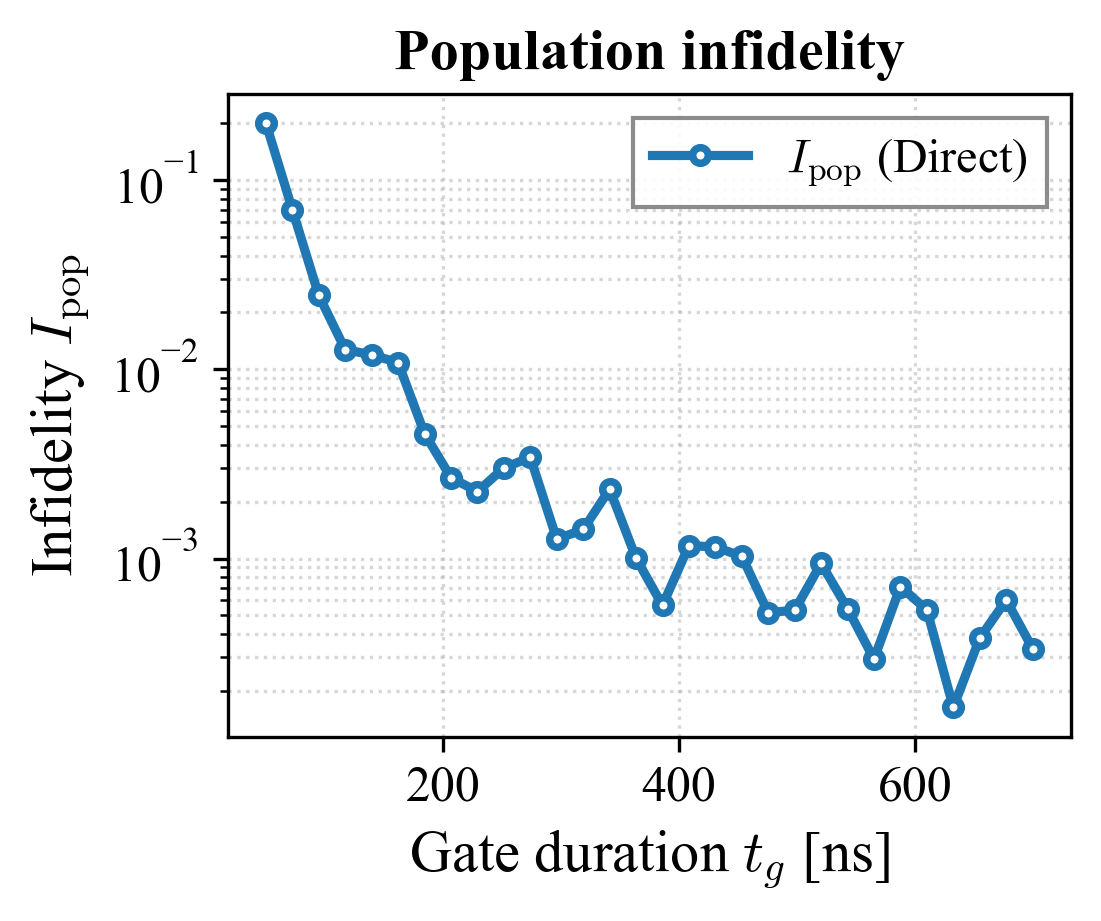

In [12]:
def plot_infidelity_vs_tg_margin(tg_list, infid_pop_list, save_path=None, show=True):
    # Standard-Paper-Style laden
    setup_paper_style()
    
    c_proc = "#1f77b4"
    
    # 1. Schriftgrößen und Liniendicken gezielt für schmale Margin-Plots hochskalieren
    margin_style = {
        "axes.labelsize": 14.0,       # Achsenbeschriftungen (tg, I_pop) deutlich größer
        "axes.titlesize": 14.0,       # Titel größer
        "xtick.labelsize": 12.0,      # Zahlen an den Ticks größer
        "ytick.labelsize": 12.0,
        "legend.fontsize": 11.5,      # Legende lesbar halten
        "lines.linewidth": 2.2,       # Dickere Linie für schmale Darstellung
        "lines.markersize": 7.5,      # Größere Marker
    }
    
    with plt.rc_context(margin_style):
        # Kompaktes Figure-Format für die Spaltenbreite des Seitenrands
        fig, ax = plt.subplots(figsize=(3.8, 3.2), dpi=300)
        
        ax.semilogy(
            tg_list, 
            infid_pop_list, 
            "-", 
            color=c_proc, 
            marker=".", 
            markerfacecolor="white", 
            markeredgecolor=c_proc,
            markeredgewidth=1.8,
            label=r"$I_{\mathrm{pop}}$ (Direct)"
        )
        
        ax.set_xlabel(r"Gate duration $t_g$ [ns]")
        ax.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
        ax.set_title(r"Population infidelity", fontweight="bold")
        
        ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
        ax.legend(loc="best", frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)
        
        # Etwas mehr Platz für die Achsenbeschriftungen lassen
        fig.tight_layout()
        
        if save_path:
            output_file = Path(save_path)
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, bbox_inches="tight")
            
        if show:
            plt.show()
            
        return fig, ax

# Ausführen
fig, ax = plot_infidelity_vs_tg_margin(tg_list, infid_pop_list, save_path="Figure/cosine_pop_infidelity_vs_tg.pdf")